In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/srei-research/SREI.csv
/kaggle/input/srei-v2/SREI v2.csv
/kaggle/input/srei-v2/SREI V3.csv
/kaggle/input/test-data/Copy of __ SREI 2023 survey (Responses) - Form Responses 1.csv


In [2]:
#Data Preprocessing
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv('/kaggle/input/srei-v2/SREI V3.csv')
df = df.rename(columns=df.iloc[0]).drop(df.index[0])
df = df.dropna()


# Assume df is your DataFrame and 'time' is the column with the times
# df['time'] = pd.to_datetime(df['time'])

# # Convert datetime to seconds from midnight

df['time'] = pd.to_datetime(df['What time do you usually wake up for school'])

df['What time do you usually wake up for school'] = df['time'].dt.hour * 3600 + df['time'].dt.minute * 60 + df['time'].dt.second

# df.drop(columns=['time'], axis =1)
for column_index in [3, 6, 7,8,10,11,12,13,14,15,16,17,18,19,20,21]:
    df.iloc[:, column_index] = df.iloc[:, column_index].astype(float)

df.head()
# print(df.head())


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/tmp/ipykernel_32/1760337023.py:21: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.iloc[:, column_index] = df.iloc[:, column_index].astype(float)


,Gender,Ethnicity,Economic Status,What is the approximate distance in miles that you travel to school currently/previously if you've already graduated? (put the number only),How do you travel to school?,Parent educational level,"How busy are you outside of school from 1-10 (work, sports, etc)",High School GPA range (Selected which one is the closest to your current GPA) (You can enter in your exact GPA below if you're interested),"How would you evaluate your academic performance during your early years, specifically up until the age of 12?","Did you feel academically successful during your adolescent years, roughly between the ages of 13 and 17?",...,Time spent on social media within a day (hours),Time spent on studying (hours),Time spent sleeping (hours),What time do you usually wake up for school,What is your interest level in reading? (1 to 10),How happy are you? (1 to 10),How safe do you feel at school? (1 to 10),How physically fit do you rate yourself? (1 to 10),Have you completed your high school education? (select no if you're still a student),time
1,Male,Hispanic,High,0.5,Walk,College Degree,3.0,1.5,6.0,No,...,3.0,3.0,8.0,25200.0,3.0,7.0,5.0,4.0,No,2023-07-29 07:00:00
2,Male,White,Medium,7.0,Public Transport,High School Diploma,3.0,3.5,7.0,Yes,...,5.0,0.0,6.0,18900.0,4.0,5.0,4.0,6.0,Yes,2023-07-29 05:15:00
3,Female,Asian,Low,4.4,Car,High School Diploma,7.0,3.0,7.0,No,...,6.0,2.0,7.0,21600.0,10.0,4.0,6.0,6.0,No,2023-07-29 06:00:00
4,Male,Asian,Low,2.0,Bike,College Degree,4.0,4.0,8.0,Yes,...,7.0,1.0,7.0,36000.0,6.0,8.0,7.0,7.0,Yes,2023-07-29 10:00:00
5,Male,Hispanic,Medium,2.0,Car,College Degree,4.0,3.5,8.0,Yes,...,1.0,0.0,7.0,24300.0,3.0,4.0,9.0,6.0,No,2023-07-29 06:45:00


In [3]:
le = LabelEncoder()

# Fit and transform the 'Race' column
df['Gender'] = le.fit_transform(df['Gender'])
df['Economic Status'] = le.fit_transform(df['Economic Status'])
df['Parent educational level'] = le.fit_transform(df['Parent educational level'])
df['Ethnicity'] = le.fit_transform(df['Ethnicity'])
df['How do you travel to school?'] = le.fit_transform(df['How do you travel to school?'])
df['Did you feel academically successful during your adolescent years, roughly between the ages of 13 and 17?'] = le.fit_transform(df['Did you feel academically successful during your adolescent years, roughly between the ages of 13 and 17?'])
df.iloc[:, 22] = le.fit_transform(df.iloc[:, 22])
# Use the model to make predictions


# print(x)
# print(y)

# print(df.iloc[:,1])
# pd.set_option('display.max_rows', df.shape[0]+1)
# print(df.iloc[:,2])

df.head(1000)
print("average " + str(df.iloc[:, 7].mean()))
range = df.iloc[:, 7].max() - df.iloc[:, 7].min()
print("range  " + str(range))
print("min  " + str(df.iloc[:, 7].min()))
print("max " + str(df.iloc[:, 7].max()))

Q1 = df.iloc[:, 7].quantile(0.25)
Q3 = df.iloc[:, 7].quantile(0.75)
IQR = Q3 - Q1
print(f"The interquartile range (IQR) for the column number 11 in the DataFrame is: {IQR}")
Q1 = df.iloc[:, 7].quantile(0.25)
Q2 = df.iloc[:, 7].quantile(0.50)
Q3 = df.iloc[:, 7].quantile(0.75)

print(f"The lower quartile (Q1) for the column number 11 in the DataFrame is: {Q1}")
print(f"The median (Q2) for the column number 11 in the DataFrame is: {Q2}")
print(f"The upper quartile (Q3) for the column number 11 in the DataFrame is: {Q3}")

average 3.569459459459459
range  2.5
min  1.5
max 4.0
The interquartile range (IQR) for the column number 11 in the DataFrame is: 0.75
The lower quartile (Q1) for the column number 11 in the DataFrame is: 3.25
The median (Q2) for the column number 11 in the DataFrame is: 3.75
The upper quartile (Q3) for the column number 11 in the DataFrame is: 4.0


/tmp/ipykernel_32/3595354509.py:10: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.iloc[:, 22] = le.fit_transform(df.iloc[:, 22])


In [4]:
df.head(100)

,Gender,Ethnicity,Economic Status,What is the approximate distance in miles that you travel to school currently/previously if you've already graduated? (put the number only),How do you travel to school?,Parent educational level,"How busy are you outside of school from 1-10 (work, sports, etc)",High School GPA range (Selected which one is the closest to your current GPA) (You can enter in your exact GPA below if you're interested),"How would you evaluate your academic performance during your early years, specifically up until the age of 12?","Did you feel academically successful during your adolescent years, roughly between the ages of 13 and 17?",...,Time spent on social media within a day (hours),Time spent on studying (hours),Time spent sleeping (hours),What time do you usually wake up for school,What is your interest level in reading? (1 to 10),How happy are you? (1 to 10),How safe do you feel at school? (1 to 10),How physically fit do you rate yourself? (1 to 10),Have you completed your high school education? (select no if you're still a student),time
1,1,1,0,0.5,3,0,3.0,1.50,6.0,1,...,3.0,3.0,8.0,25200.0,3.0,7.0,5.0,4.0,0,2023-07-29 07:00:00
2,1,3,2,7.0,2,1,3.0,3.50,7.0,2,...,5.0,0.0,6.0,18900.0,4.0,5.0,4.0,6.0,1,2023-07-29 05:15:00
3,0,0,1,4.4,1,1,7.0,3.00,7.0,1,...,6.0,2.0,7.0,21600.0,10.0,4.0,6.0,6.0,0,2023-07-29 06:00:00
4,1,0,1,2.0,0,0,4.0,4.00,8.0,2,...,7.0,1.0,7.0,36000.0,6.0,8.0,7.0,7.0,1,2023-07-29 10:00:00
5,1,1,2,2.0,1,0,4.0,3.50,8.0,2,...,1.0,0.0,7.0,24300.0,3.0,4.0,9.0,6.0,0,2023-07-29 06:45:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,1,0,1,3.0,1,2,7.0,3.50,9.0,1,...,3.0,1.0,7.0,23400.0,6.0,7.0,6.0,6.0,0,2023-07-29 06:30:00
73,1,0,2,3.5,1,0,6.0,3.50,10.0,0,...,5.0,2.0,8.0,26400.0,7.0,7.0,8.0,7.0,0,2023-07-29 07:20:00
74,1,1,2,3.0,1,1,8.0,3.78,9.0,0,...,1.0,0.0,8.0,25200.0,5.0,8.0,7.0,7.0,1,2023-07-29 07:00:00
75,1,0,2,3.0,1,1,6.0,4.00,10.0,2,...,4.0,4.0,8.0,21600.0,4.0,7.0,6.0,7.0,0,2023-07-29 06:00:00


In [5]:
#ML Model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

model = DecisionTreeRegressor()
model_rf = RandomForestRegressor(n_estimators=1000, random_state=42)




training_df = df.sample(frac=0.80, random_state=42)


train_y = training_df.iloc[:, [7]]
train_x = training_df.iloc[:, [2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]]

test_df = df.drop(training_df.index)

test_y = test_df.iloc[:, [7]]
test_x = test_df.iloc[:, [2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]]

# train_x = x
# train_y = y
# train_x =x.sample(frac=0.9, random_state=1)
# train_y =y.sample(frac=0.9, random_state=1)


model.fit(train_x,train_y)
model_rf.fit(train_x,train_y)

# model.fit(x[:80], y[:80])


# print(x)

/tmp/ipykernel_32/3649572965.py:29: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_rf.fit(train_x,train_y)


RandomForestRegressor(n_estimators=1000, random_state=42)

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 20, 50)            2600      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 128)               22912     
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 25,641
Trainable params: 25,641
Non-trainable params: 0
_________________________________________________________________
Epoch 1/80
2/2 [==============================] - 3s 448ms/step - loss: 20.0801 - rmse: 4.4811 - val_loss: 6.7140 - val_rmse: 2.5911
Epoch 2/80
2/2 [==============================] - 0s 55ms/step - loss: 3.9179 - rmse: 1.9794 - val_loss: 0.6736 - val_rmse: 0.8207
Epoch 3/80
2/2 [==============================] - 0s

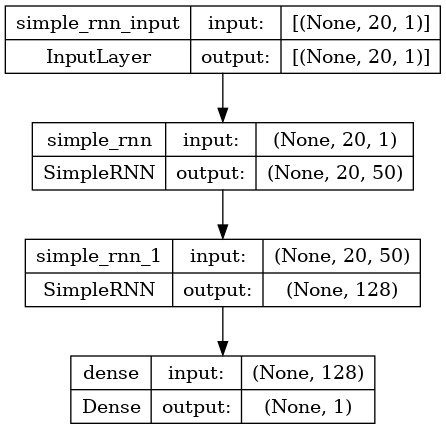

In [6]:
#Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout,SimpleRNN 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping


# Define a 1D CNN model
RNNmodel = Sequential()
# CNNmodel.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(11,1)))
# CNNmodel.add(Conv1D(64, kernel_size=3, activation='relu'))
# CNNmodel.add(Dropout(0.5))  # Dropout layer
# CNNmodel.add(Conv1D(128, kernel_size=3, activation='relu'))
# CNNmodel.add(Conv1D(64, kernel_size=3, activation='relu'))
# CNNmodel.add(Conv1D(32, kernel_size=3, activation='relu'))
# CNNmodel.add(Dropout(0.6))  # Dropout layer
# CNNmodel.add(Dense(1)) # No activation function for regression
# Compile the model

#RNN
RNNmodel.add(SimpleRNN(50, input_shape=(20, 1), return_sequences=True))
# CNNmodel.add(SimpleRNN(128))
# CNNmodel.add(SimpleRNN(128))
RNNmodel.add(SimpleRNN(128))


# CNNmodel.add(Dense(32, input_shape=(11,), activation='relu'))  # Here, 11 is the number of features in the input data

# # Add hidden layers
# CNNmodel.add(Dense(64, activation='relu'))
# CNNmodel.add(Dense(128, activation='relu'))

# Add output layer
RNNmodel.add(Dense(1))  # For regression tasks, the output layer has a linear activation function


optimizer = Adam(learning_rate=0.0000001)
early_stopping = EarlyStopping(monitor='val_loss', patience=100)
RNNmodel.compile(optimizer='adam', loss='mean_squared_error', metrics=[RootMeanSquaredError(name='rmse')])

# Print a summary of the model
RNNmodel.summary()

RNNPrediction = RNNmodel.fit(train_x, train_y,epochs = 80, batch_size = 32, validation_data=(test_x, test_y),callbacks = [early_stopping])



# Plot the model
plot_model(RNNmodel, to_file='model_plot_rnn.png', show_shapes=True, show_layer_names=True)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 18, 32)            128       
                                                                 
 conv1d_1 (Conv1D)           (None, 16, 128)           12416     
                                                                 
 conv1d_2 (Conv1D)           (None, 14, 128)           49280     
                                                                 
 conv1d_3 (Conv1D)           (None, 12, 128)           49280     
                                                                 
 conv1d_4 (Conv1D)           (None, 10, 32)            12320     
                                                                 
 flatten (Flatten)           (None, 320)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                

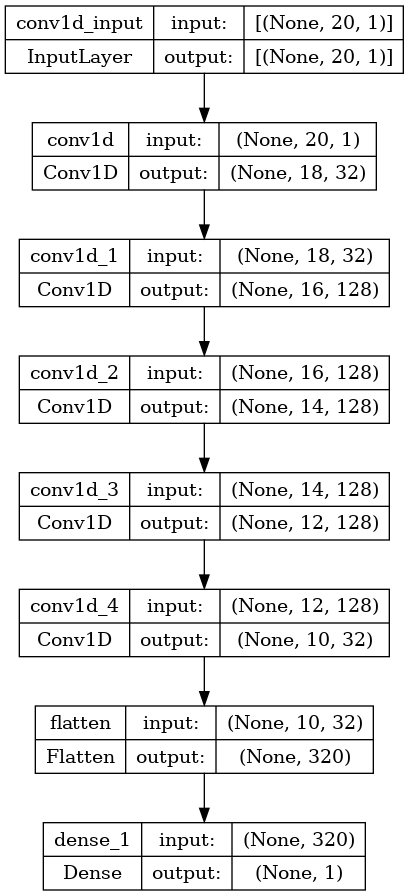

In [7]:
#Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout,SimpleRNN 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping


# Define a 1D CNN model
CNNmodel = Sequential()
CNNmodel.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(20,1)))
CNNmodel.add(Conv1D(128, kernel_size=3, activation='relu'))
# CNNmodel.add(Dropout(0.5))  # Dropout layer
CNNmodel.add(Conv1D(128, kernel_size=3, activation='relu'))
CNNmodel.add(Conv1D(128, kernel_size=3, activation='relu'))
CNNmodel.add(Conv1D(32, kernel_size=3, activation='relu'))
# CNNmodel.add(Dropout(0.6))  # Dropout layer
CNNmodel.add(Flatten())
CNNmodel.add(Dense(1)) # No activation function for regression
# Compile the model

#RNN
# CNNmodel.add(SimpleRNN(128))
# CNNmodel.add(SimpleRNN(128))


# CNNmodel.add(Dense(32, input_shape=(11,), activation='relu'))  # Here, 11 is the number of features in the input data

# # Add hidden layers
# CNNmodel.add(Dense(64, activation='relu'))
# CNNmodel.add(Dense(128, activation='relu'))

# Add output layer
 # For regression tasks, the output layer has a linear activation function


optimizer = Adam(learning_rate=0.0000001)
early_stopping = EarlyStopping(monitor='val_loss', patience=100)
CNNmodel.compile(optimizer='adam', loss='mean_squared_error', metrics=[RootMeanSquaredError(name='rmse')])

# Print a summary of the model
CNNmodel.summary()

CNNPrediction = CNNmodel.fit(train_x, train_y,epochs = 600, batch_size = 32, validation_data=(test_x, test_y),callbacks = [early_stopping])



# Plot the model
plot_model(CNNmodel, to_file='model_plot_cnn.png', show_shapes=True, show_layer_names=True)


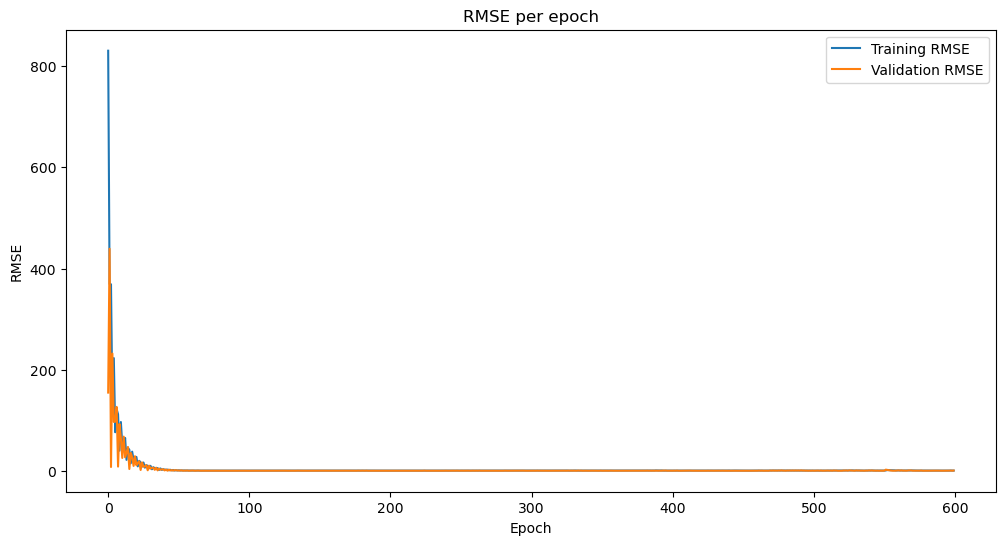

In [8]:
import matplotlib.pyplot as plt

# Assume `model` is your Keras model
# weights = CNNmodel.layers[0].get_weights()[0]  # Change the index based on the layer you want

# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.hist(weights.flatten())
# plt.xlabel('Weight values')
# plt.ylabel('Frequency')
# plt.title('Histogram of weight values')

# plt.subplot(1, 2, 2)
# plt.imshow(weights, cmap='viridis', interpolation='none')
# plt.xlabel('Neurons in layer n')
# plt.ylabel('Input features')
# plt.title('Weights of layer n')
# plt.show()


plt.figure(figsize=(12, 6))
plt.plot(CNNPrediction.history['rmse'], label='Training RMSE')
plt.plot(CNNPrediction.history['val_rmse'], label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('RMSE per epoch')
plt.legend()
plt.show()


In [9]:
from scipy.stats import pearsonr
from scipy import stats
import numpy as np

# List of columns to compare with
columns_to_compare = df.iloc[:, [2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]]

# Dictionaries to hold p-values, correlation coefficients and standard errors
p_values = {}
correlation_coefficients = {}
standard_errors = {}

# Calculate p-value and correlation coefficient for each column
for column in columns_to_compare:
    corr_coeff, p_value = pearsonr(df.iloc[:,7], df[column])
    p_values[column] = p_value
    correlation_coefficients[column] = corr_coeff
    # Calculate standard error of the estimate
    y_pred = corr_coeff * df.iloc[:,7]
    standard_errors[column] = np.std(df[column] - y_pred)

# Print each column name along with its p-value and correlation coefficient
for column in p_values:
    p_value = p_values.get(column)
    corr_coeff = correlation_coefficients.get(column)
    std_err = standard_errors.get(column)
    if p_value < 0.05:
        print(f"The p-value for '{column}' is {p_value}, the correlation coefficient is {corr_coeff}, and the standard error is {std_err}")


The p-value for 'How would you evaluate your academic performance during your early years, specifically up until the age of 12?' is 0.037104435353758736, the correlation coefficient is 0.24282555466678066, and the standard error is 1.5193673345093957
The p-value for 'On a scale of 1 to 10, how would you assess your work ethic, taking into consideration factors such as time management, organizational abilities, and performance?
' is 0.012339615531935215, the correlation coefficient is 0.28955337444806484, and the standard error is 1.7874747875877517
The p-value for 'How happy are you? (1 to 10)' is 0.01831169977865763, the correlation coefficient is 0.2736590637344832, and the standard error is 1.8851695149610148


/tmp/ipykernel_32/2055904780.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlations = df.corr().iloc[7].drop(df.columns[7])


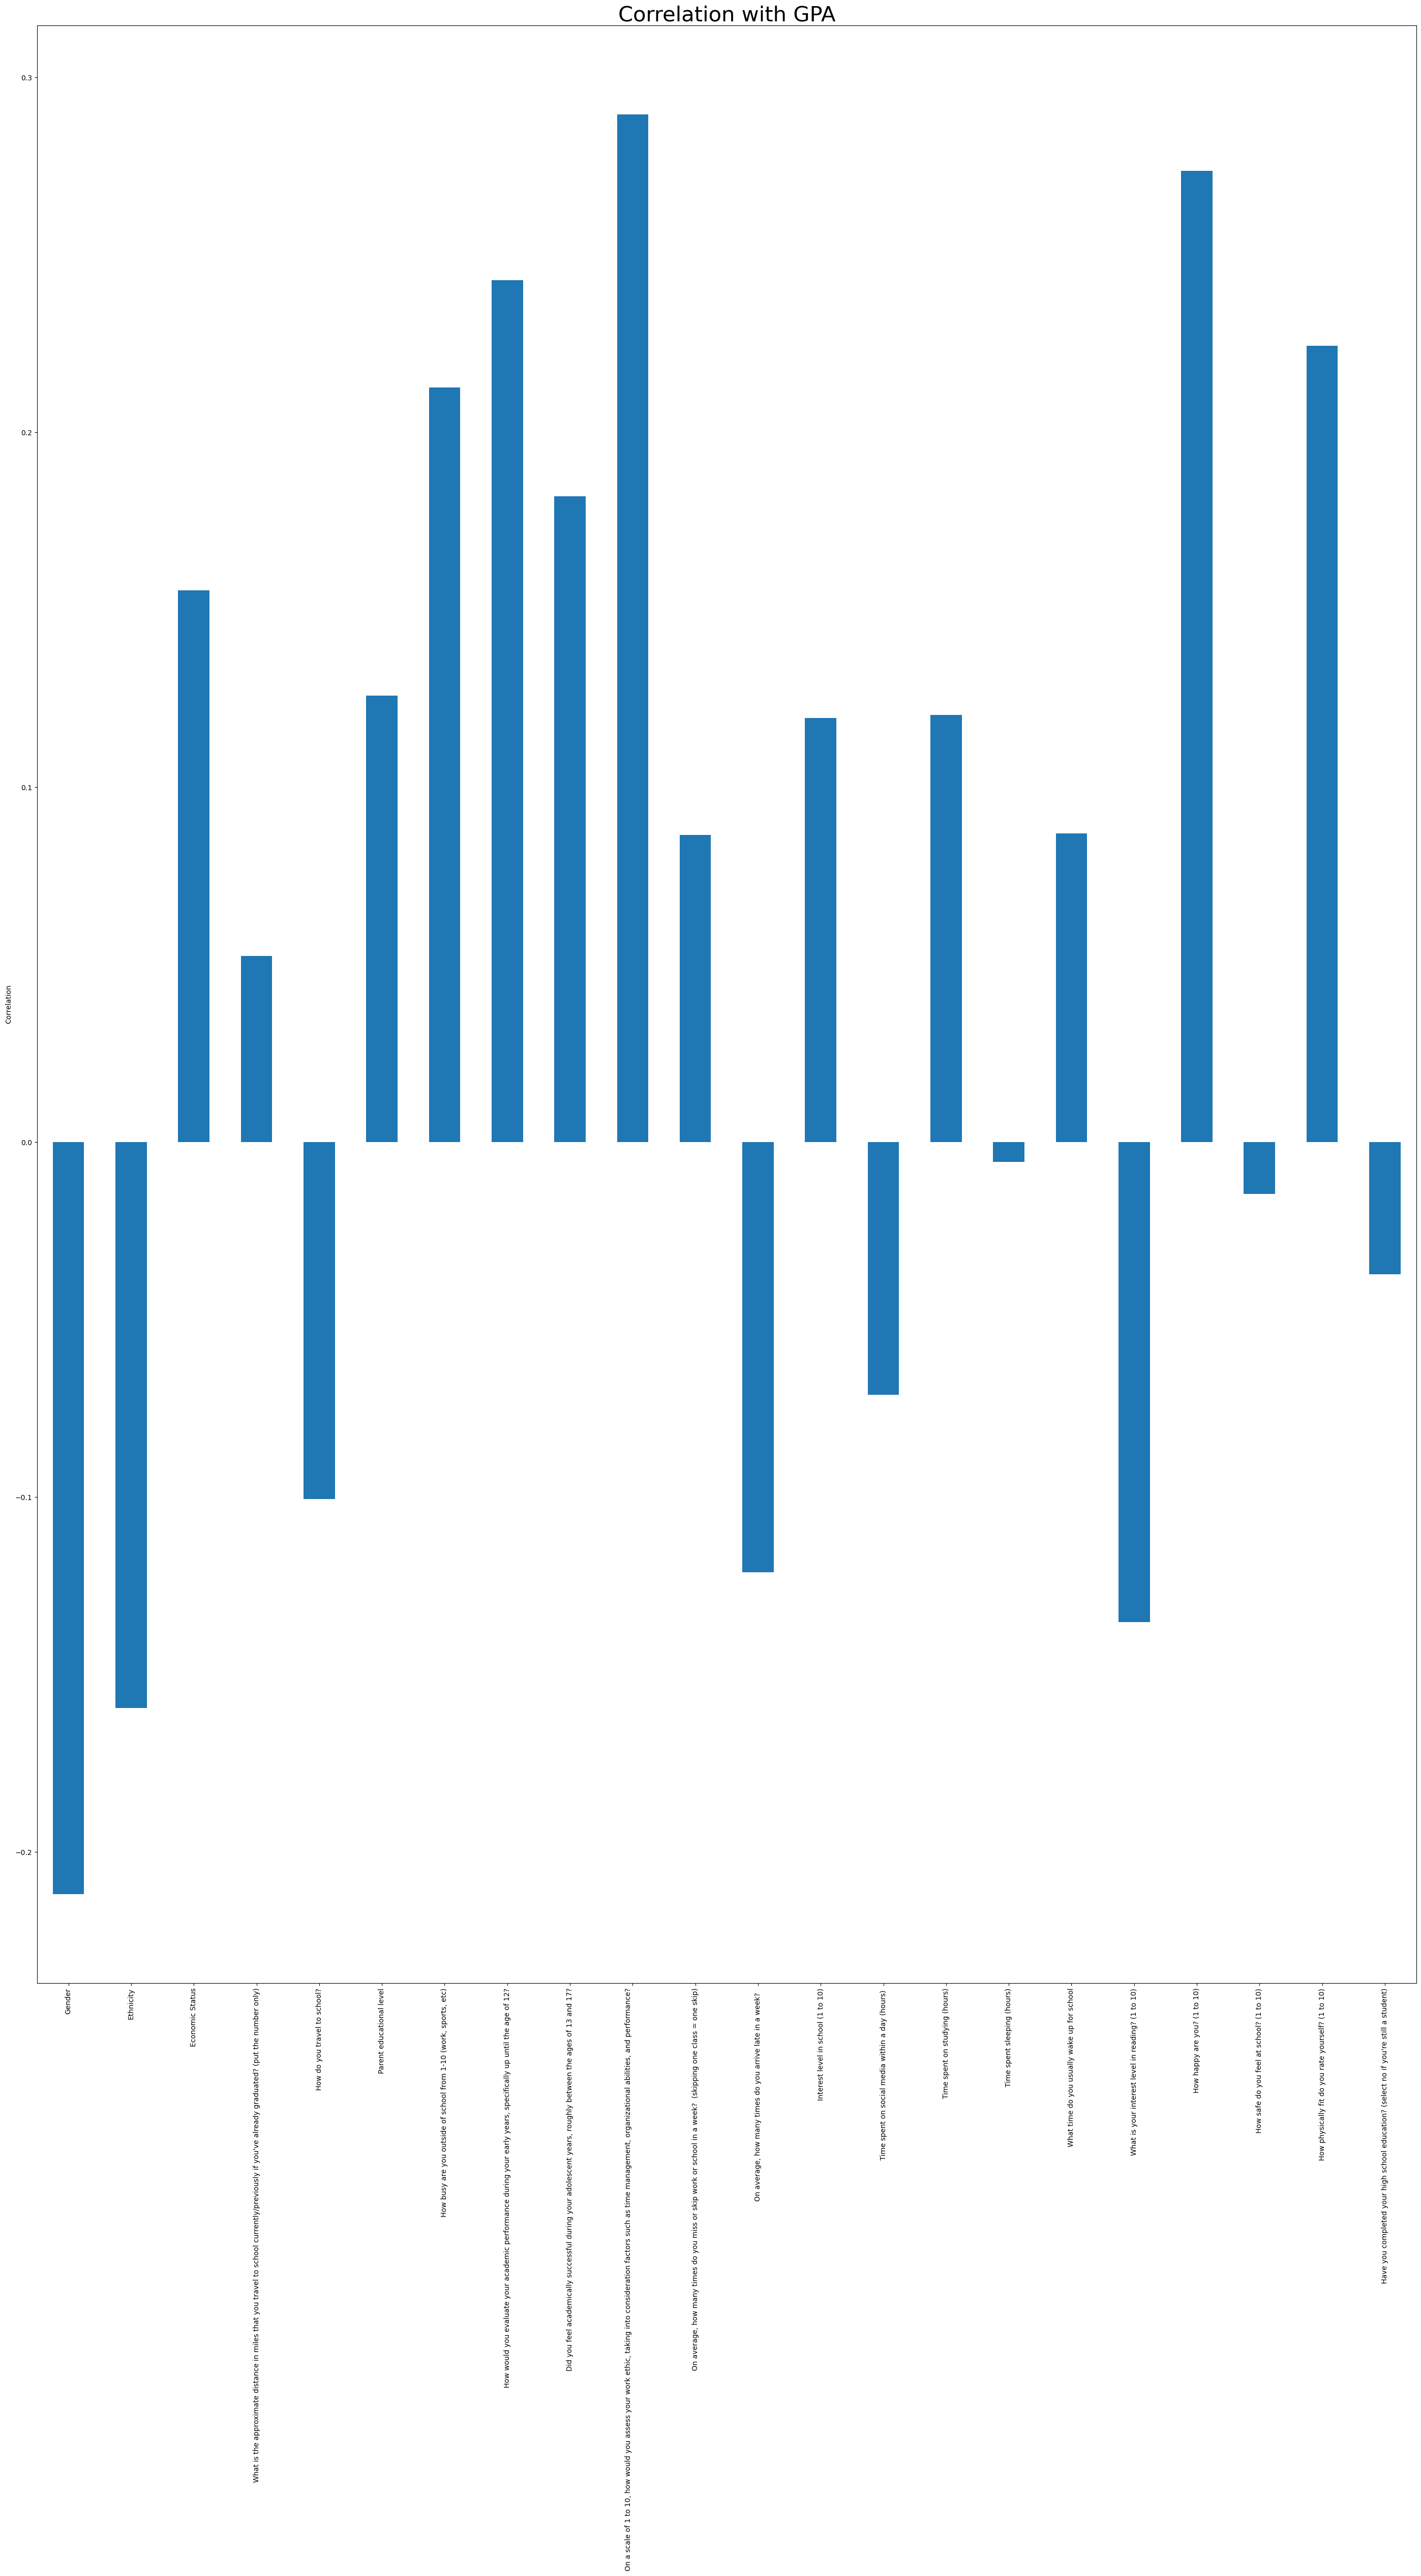

In [10]:
#Find Correlation
import matplotlib.pyplot as plt

correlations = df.corr().iloc[7].drop(df.columns[7])
correlations.plot(kind='bar', figsize=(35, 50))
plt.rcParams.update({'font.size': 25})
plt.title('Correlation with GPA')
plt.ylabel('Correlation')
plt.savefig('correlation_plot.png', bbox_inches='tight')

plt.show()


In [11]:
# Visualize Decision Tree
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
import pydot
from matplotlib import image as mpimg


# # Visualize the decision tree
fig, ax = plt.subplots(figsize=(65, 24), dpi=250
                      )
tree.plot_tree(model, feature_names=train_x.columns, class_names=train_y, filled=True, max_depth = 2)
plt.savefig('decision_tree.png')
plt.show()

# dot_data = tree.export_graphviz(model, out_file=None, feature_names=train_x.columns, class_names=train_y.unique(),
#                                 filled=True)

# # Modify the dot file to adjust the leaf overlap
# graph = pydot.graph_from_dot_data(dot_data)[0]
# graph.set_orientation('vertical')
# graph.set_overlap(0)
# graph.write('decision_tree.dot')

# Save the modified dot file as an image
# graph.write_png('decision_tree.png')

# # Display the image
# img = mpimg.imread('decision_tree.png')
# plt.figure(figsize=(250, 300))
# plt.imshow(img,aspect='auto')
# plt.axis('off')
#plt.savefig('decision_tree.png')
# plt.show()/kaggle/working/decision_tree.dot

In [12]:
#Evaluation
from sklearn.metrics import mean_squared_error
# print(x.iloc[1])
# print(model.predict(x.iloc[1]))
# print(x.head())

predicted_value = model.predict(test_x)
mse = mean_squared_error(test_y, predicted_value)
rmse = np.sqrt(mse)

print("mse_dt " + str(mse))
print("rmse_dt " + str(rmse))

predicted_value_rf = model_rf.predict(test_x)
mse = mean_squared_error(test_y, predicted_value_rf)
rmse = np.sqrt(mse)

print("mse_rf " + str(mse))
print("rmse_rf " + str(rmse))

predicted_value_rnn = RNNmodel.predict(test_x)

mse = mean_squared_error(test_y,predicted_value_rnn)
rmse = np.sqrt(mse)

print("mse_rnn " +str(mse))
print("rmse_rnn " +str(rmse))

predicted_value_cnn = CNNmodel.predict(test_x)

# print(predicted_value_cnn)
mse = mean_squared_error(test_y,predicted_value_cnn)
rmse = np.sqrt(mse)

print("mse_cnn " +str(mse))
print("rmse_cnn " +str(rmse))





# prediction = test_x
# prediction['Predicted'] = predicted_value
# # prediction.drop(df.index[20:], inplace=True)
# prediction.head(150)

mse_dt 0.47692
rmse_dt 0.6905939472656852
mse_rf 0.15258218219333303
rmse_rf 0.3906176931391268
1/1 [==============================] - 0s 297ms/step
mse_rnn 0.11254911125595231
rmse_rnn 0.3354833993746223
1/1 [==============================] - 0s 120ms/step
mse_cnn 0.752227110445028
rmse_cnn 0.8673102734575603


In [13]:
print(predicted_value_cnn)

[[2.2111151]
 [2.5006697]
 [3.0282538]
 [3.378504 ]
 [2.7771018]
 [3.3023322]
 [3.2857459]
 [2.8735373]
 [1.9988273]
 [2.903559 ]
 [2.6679633]
 [2.655306 ]
 [3.1354544]
 [2.9996436]
 [2.9949896]]


In [14]:
compare = pd.DataFrame()
compare['Actual GPA'] = test_df.iloc[:,7]
compare['Predicted_dt'] = predicted_value
compare['Predicted_rf'] = predicted_value_rf
compare["Predicted_RNN"] = predicted_value_rnn
compare["Predicted_CNN"] = predicted_value_cnn


compare.head(100)




,Actual GPA,Predicted_dt,Predicted_rf,Predicted_RNN,Predicted_CNN
2,3.50,3.25,3.10451,3.609953,2.211115
3,3.00,2.75,3.46886,3.516815,2.500670
15,4.00,4.00,3.52916,3.788942,3.028254
21,4.00,4.00,3.39345,3.741771,3.378504
22,4.00,4.00,3.85889,3.704120,2.777102
25,4.00,3.75,3.40218,3.601586,3.302332
32,3.25,1.50,3.16891,3.405575,3.285746
40,3.25,2.75,3.19639,3.149962,2.873537
46,3.50,4.00,3.47650,3.454595,1.998827
54,3.73,3.50,3.39208,3.468031,2.903559


In [15]:
#test everything so im not going crazy
df.head(100)

df_x = df.iloc[:, [0, 1, 2,3,4,5,6,7,8,9,10]]

df_x.head(1000)

values = model.predict(df_x)

df['Predicted'] = values
df.head(1000)



ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Ethnicity
- Gender
- High School GPA range (Selected which one is the closest to your current GPA) (You can enter in your exact GPA below if you're interested)
Feature names seen at fit time, yet now missing:
- Have you completed your high school education? (select no if you're still a student)
- How happy are you? (1 to 10)
- How physically fit do you rate yourself? (1 to 10)
- How safe do you feel at school? (1 to 10)
- Interest level in school (1 to 10)
- ...
